# Exploratory Data Analysis of Player Performance and Market Value

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load Dataset

In [ ]:
df = pd.read_excel("yigitdsa210data.xlsx")
df.head()

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,Gls,Ast,G+A,Gls.1,Ast.1,Market Value
0,Miguel Almirón,py PAR,FW,Newcastle United,30.0,1994.0,9.0,1,157.000,0.0,0.0,0.0,0.00,0.00,€18.00m
1,Michail Antonio,jm JAM,FW,West Ham United,34.0,1990.0,14.0,11,836.000,1.0,1.0,2.0,0.11,0.11,€6.00m
2,Antony,br BRA,"FW,MF",Manchester Utd,24.0,2000.0,8.0,0,141.000,0.0,0.0,0.0,0.00,0.00,€40.00m
3,Cameron Archer,eng ENG,FW,Southampton,23.0,2001.0,35.0,13,1.441,2.0,0.0,2.0,0.12,0.00,€18.00m
4,Adam Armstrong,eng ENG,"FW,MF",Southampton,27.0,1997.0,20.0,15,1.248,2.0,2.0,4.0,0.14,0.14,€18.00m


# Data Cleaning and Preprocessing

In [ ]:
def convert_market_value(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = x.replace("€", "").lower()

    if x.endswith("m"):
        return float(x[:-1]) * 1000000
    elif x.endswith("k"):
        return float(x[:-1]) * 1000
    else:
        return float(x)

df["Market Value Numeric"] = df["Market Value"].apply(convert_market_value)

# Dataset Overview

In [ ]:
numeric_columns = ["Age", "MP", "Starts", "Min", "Gls", "Ast", "G+A", "Market Value Numeric"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=numeric_columns)

In [ ]:
df[["Gls", "Ast", "G+A", "Market Value Numeric"]].head()

,Gls,Ast,G+A,Market Value Numeric
0,0.0,0.0,0.0,18000000.0
1,1.0,1.0,2.0,6000000.0
2,0.0,0.0,0.0,40000000.0
3,2.0,0.0,2.0,18000000.0
4,2.0,2.0,4.0,18000000.0


# Correlation Analysis

In [ ]:
corr, p_value = pearsonr(df["G+A"], df["Market Value Numeric"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.4404282327592456
P-value: 2.580544136825974e-06


# Performance vs Market Value

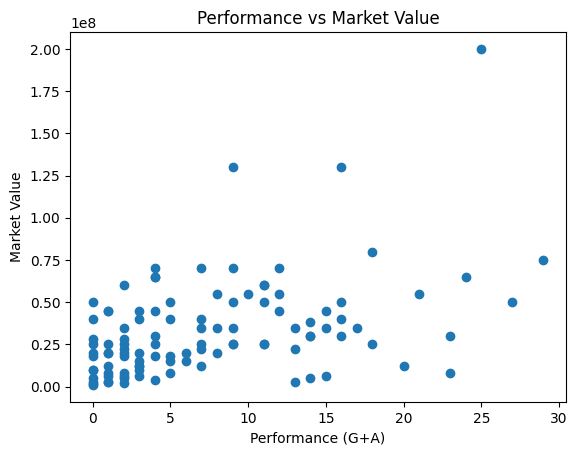

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["G+A"], df["Market Value Numeric"])
plt.xlabel("Performance (G+A)")
plt.ylabel("Market Value")
plt.title("Performance vs Market Value")
plt.show()

# Log-Log Relationship Analysis

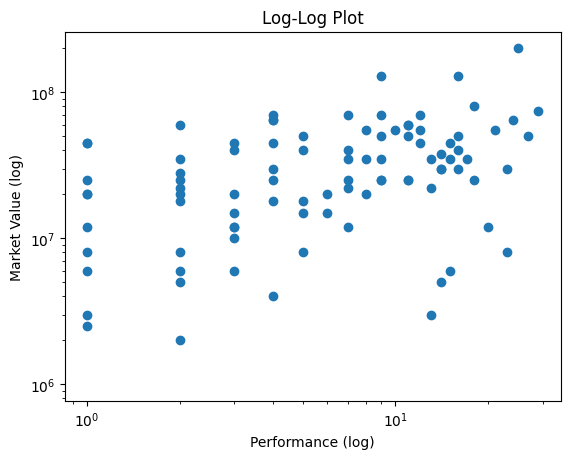

In [ ]:
plt.scatter(df["G+A"], df["Market Value Numeric"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Performance (log)")
plt.ylabel("Market Value (log)")
plt.title("Log-Log Plot")
plt.show()

# Key Findings and Interpretation

The correlation between performance (G+A) and market value is moderately positive.

This shows that players who score and assist more generally have higher market values.

The p-value is very small, which means the relationship is statistically significant and not due to random chance.

The scatter plot shows a general upward trend, but also some variation between players.

The log-log plot makes the relationship clearer by reducing the effect of extreme values.

This suggests that performance is an important factor in determining market value, but other factors such as age, team, and popularity may also play a role.

# Age and Market Value Analysis

In [ ]:
corr_age, p_age = pearsonr(df["Age"], df["Market Value Numeric"])

print("Age Correlation:", corr_age)
print("Age P-value:", p_age)

Age Correlation: -0.09199358725558825
Age P-value: 0.3506388608558581


## Age vs Market Value

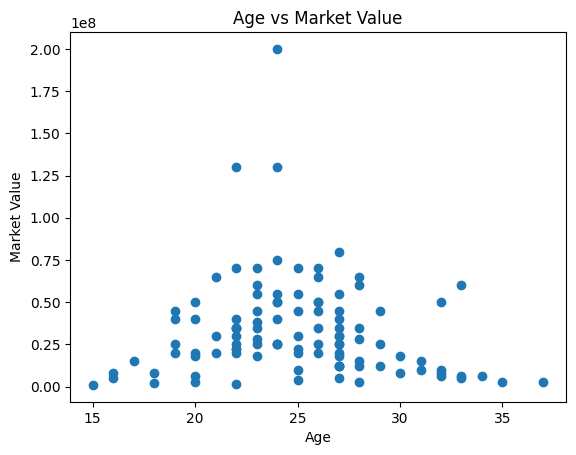

In [ ]:
plt.scatter(df["Age"], df["Market Value Numeric"])

plt.xlabel("Age")
plt.ylabel("Market Value")
plt.title("Age vs Market Value")

plt.show()

# Conclusion

The relationship between age and market value appears to be weak.

The correlation value is close to zero, and the p-value is relatively high, which suggests that age alone is not a statistically significant predictor of market value in this dataset.

Although some younger players have high market values, the overall pattern is not very strong.

This indicates that performance statistics may have a greater impact on market value than age alone.